# Fine-tuning figures

Outputs go to **visualizations/out/** via **plot_ft.py**.

| # | Figure | Data |
|---|--------|------|
| 1 | Train/eval loss (+ LR panel) | trainer_state.json under a run dir |
| 2 | Input vs target lengths | output/training_data/<task>/train.json |
| 3 | Exact match grouped bars | RESULTS_DIR JSONs |
| 4 | Train/dev/test **sizes** per task | same training JSON tree |
| 5 | **Heatmap** model × eval task | RESULTS_DIR (cross-task transfer) |
| 6 | **Prompt-style** heatmap (0/1/few × task) | BASELINE_DIR + slug pattern |
| 7 | **Combined** structured field bars | RESULTS_DIR |

Edit **REPO**, **RUN_DIR**, **RESULTS_DIR**, **BASELINE_DIR**, **MODEL_ID** in the config cell.

**Deps:** matplotlib; token lengths need **transformers**.

In [8]:
import os
from pathlib import Path

# Headless-safe plotting in notebooks / servers
os.environ.setdefault("MPLBACKEND", "Agg")

_here = Path.cwd()
if (_here / "evaluation").is_dir():
    REPO = _here
elif (_here.parent / "evaluation").is_dir():
    REPO = _here.parent
else:
    REPO = Path("..").resolve()

OUT_DIR = REPO / "visualizations" / "out"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# LoRA run: either the timestamped run dir, or the task folder (next cell finds newest trainer_state.json under it)
RUN_DIR = REPO / "sft_full" / "meter_only_lora"
# Or set explicitly, e.g. after training completes:
# RUN_DIR = REPO / "sft_full" / "meter_only_lora" / "flan-t5-large_lora_20260413_210437"

# SFT / LoRA eval JSONs (slug subdirs)
RESULTS_DIR = REPO / "results"
# Pretrained prompt-only baselines (for prompt-style heatmap)
BASELINE_DIR = REPO / "evaluation" / "baselines"

MODEL_ID = "google/flan-t5-large"  # token-length histograms; None = char counts only

In [9]:
import sys

# Import plot_ft as a package module (avoids stale/shadowed top-level `plot_ft`)
_repo = str(REPO.resolve())
if _repo not in sys.path:
    sys.path.insert(0, _repo)

from visualizations.plot_ft import (
    plot_train_val_loss,
    length_histograms,
    plot_baseline_vs_lora,
    plot_dataset_split_counts,
    plot_eval_em_heatmap,
    plot_prompt_style_heatmap,
    plot_combined_structured_by_slug,
)

def resolve_run_dir(base: Path) -> Path:
    """Pick the newest trainer_state.json under base (recursive)."""
    base = base.resolve()
    if not base.exists():
        return base
    if (base / "trainer_state.json").is_file():
        return base
    subs = sorted(base.rglob("trainer_state.json"), key=lambda p: p.stat().st_mtime, reverse=True)
    if subs:
        return subs[0].parent
    return base

run_dir = resolve_run_dir(RUN_DIR)
print("Using run_dir:", run_dir)
if not (run_dir / "trainer_state.json").is_file():
    print("Hint: set RUN_DIR to a folder that contains trainer_state.json (e.g. …/meter_only_lora/<run_id>).")

Using run_dir: /Users/kemiomoniyi/Senior Thesis/sft_full/meter_only_lora
Hint: set RUN_DIR to a folder that contains trainer_state.json (e.g. …/meter_only_lora/<run_id>).


## 1. Train / validation loss

Reads trainer_state.json from the run directory.

In [10]:
from pathlib import Path

if (run_dir / "trainer_state.json").is_file():
    plot_train_val_loss(
        run_dir,
        out_path=OUT_DIR / "train_val_loss.png",
        with_learning_rate=True,
    )
    display_path = OUT_DIR / "train_val_loss.png"
    print("Saved", display_path)
    from IPython.display import Image, display
    display(Image(filename=str(display_path)))
else:
    print("No trainer_state.json at", run_dir, "— set RUN_DIR to a completed LoRA run.")

No trainer_state.json at /Users/kemiomoniyi/Senior Thesis/sft_full/meter_only_lora — set RUN_DIR to a completed LoRA run.


## 2. Input / target length histograms

Loads output/training_data/<task>/<split>.json.

In [11]:
for task in ("meter_only", "rhyme_only", "combined"):
    out = OUT_DIR / f"lengths_{task}_train.png"
    length_histograms(
        task,
        split="train",
        data_root=REPO / "output" / "training_data",
        model_id=MODEL_ID,
        out_path=out,
    )
    print("Saved", out)

Saved /Users/kemiomoniyi/Senior Thesis/visualizations/out/lengths_meter_only_train.png


Token indices sequence length is longer than the specified maximum sequence length for this model (642 > 512). Running this sequence through the model will result in indexing errors


Saved /Users/kemiomoniyi/Senior Thesis/visualizations/out/lengths_rhyme_only_train.png


Token indices sequence length is longer than the specified maximum sequence length for this model (642 > 512). Running this sequence through the model will result in indexing errors


Saved /Users/kemiomoniyi/Senior Thesis/visualizations/out/lengths_combined_train.png


## 3. Exact match — baseline vs fine-tuned

Scans RESULTS_DIR/<slug>/*.json (same as summarize_prompt_baselines). Adjust --slug-glob on the CLI if you need to filter.

Saved /Users/kemiomoniyi/Senior Thesis/visualizations/out/exact_match_bars.png


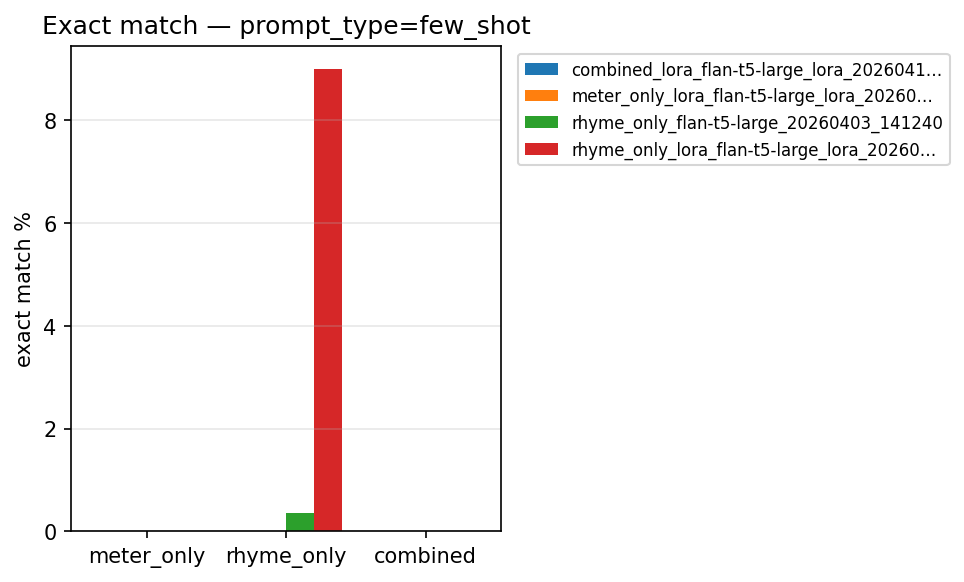

In [12]:
if RESULTS_DIR.is_dir():
    out = OUT_DIR / "exact_match_bars_zero_shot.png"
    plot_baseline_vs_lora(
        RESULTS_DIR,
        prompt_type="zero_shot",
        out_path=out,
    )
    print("Saved", out)
    from IPython.display import Image, display
    display(Image(filename=str(out)))
else:
    print("Missing", RESULTS_DIR)

## 4. How much data each SFT task uses

Bar chart: example counts for **train / dev / test** per task (same JSON the notebook uses for training).

In [13]:
out = OUT_DIR / "dataset_split_counts.png"
plot_dataset_split_counts(data_root=REPO / "output" / "training_data", out_path=out)
print("Saved", out)

Saved /Users/kemiomoniyi/Senior Thesis/visualizations/out/dataset_split_counts.png


## 5. Cross-task view (heatmap)

Rows = each **model slug**, columns = **eval task** (meter / rhyme / combined). One cell = exact match % for that eval. This is the clearest picture of **transfer** (e.g. meter-trained model on rhyme test).

In [14]:
if RESULTS_DIR.is_dir():
    out = OUT_DIR / "eval_em_heatmap_zero_shot.png"
    plot_eval_em_heatmap(RESULTS_DIR, prompt_type="zero_shot", out_path=out)
    print("Saved", out)
else:
    print("Missing", RESULTS_DIR)

Saved /Users/kemiomoniyi/Senior Thesis/visualizations/out/eval_em_heatmap_few_shot.png


## 6. Prompt-only sensitivity (pretrained backbone)

For **one** Hub slug (pattern below), how **zero / one / few**-shot prompting changes exact match on each task — before any LoRA.

In [15]:
if BASELINE_DIR.is_dir():
    out = OUT_DIR / "prompt_style_heatmap_flan_large.png"
    plot_prompt_style_heatmap(
        BASELINE_DIR,
        slug_glob="google_flan-t5-large",
        out_path=out,
    )
    print("Saved", out)
else:
    print("Missing", BASELINE_DIR)

Saved /Users/kemiomoniyi/Senior Thesis/visualizations/out/prompt_style_heatmap_flan_large.png


## 7. Combined task — structured fields vs string EM

For **combined** gold bundles: per-field match rates (stress, rhyme, …) and **mean field** / **all fields** — often informative when **full-string exact match** is near zero.

In [16]:
if RESULTS_DIR.is_dir():
    out = OUT_DIR / "combined_structured_fields_zero_shot.png"
    plot_combined_structured_by_slug(RESULTS_DIR, prompt_type="zero_shot", out_path=out)
    print("Saved", out)
else:
    print("Missing", RESULTS_DIR)

Saved /Users/kemiomoniyi/Senior Thesis/visualizations/out/combined_structured_fields.png
